This script was adapted from a script written by Celeste Cohen and performs gene clustering based on eQTL interaction beta values

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import zscore
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import pairwise_distances
from matplotlib import pyplot as plt
from matplotlib.ticker import ScalarFormatter
import math
import seaborn as sb
import sklearn
import scipy
print(sklearn.__version__)
print(scipy.__version__)

1.5.1
1.11.0


In [3]:
time_interaction_fname="genotyping/analysis/eQTL/output_data/interactions_flanders_2/time_interactions_flanders_forclust_2.csv"
outfile_path="genotyping/analysis/eQTL/output_data/interactions_flanders_2/time_interaction_clusters_2.csv"
fig_dir = "genotyping/analysis/eQTL/output_data/interactions_flanders_2/"

In [4]:
time_interactions=pd.read_csv(time_interaction_fname)
time_interactions.head()

,gsp,wk12,wk20,wk28,wk36
0,ENSG00000008128_rs3936009,0.194809,0.242214,0.271543,0.291736
1,ENSG00000008130_rs2281171,0.114405,0.123508,0.128192,0.165701
2,ENSG00000026751_rs518721,0.076467,0.072187,0.122085,0.090941
3,ENSG00000057252_rs56303406,0.127166,0.145090,0.123382,0.109936
4,ENSG00000066027_rs17018853,0.448799,0.452555,0.427522,0.410463


In [5]:
# Step 1: Set Gene_snp_pair as index
df_beta_indexed = time_interactions.set_index("gsp")
df_beta_indexed

,wk12,wk20,wk28,wk36
gsp,,,,
ENSG00000008128_rs3936009,0.194809,0.242214,0.271543,0.291736
ENSG00000008130_rs2281171,0.114405,0.123508,0.128192,0.165701
ENSG00000026751_rs518721,0.076467,0.072187,0.122085,0.090941
ENSG00000057252_rs56303406,0.127166,0.145090,0.123382,0.109936
ENSG00000066027_rs17018853,0.448799,0.452555,0.427522,0.410463
...,...,...,...,...
ENSG00000182484_23.156005065_T_C,0.150457,0.157461,0.186911,0.233447
ENSG00000189221_rs4824498,1.144004,0.991984,1.037591,0.930239
ENSG00000189326_rs10521836,0.346444,0.555073,0.736658,0.731799


In [6]:
# Make the df long
df_long = df_beta_indexed.reset_index().melt(
    id_vars='gsp',
    var_name='timepoint',
    value_name='beta'
)
df_long

,gsp,timepoint,beta
0,ENSG00000008128_rs3936009,wk12,0.194809
1,ENSG00000008130_rs2281171,wk12,0.114405
2,ENSG00000026751_rs518721,wk12,0.076467
3,ENSG00000057252_rs56303406,wk12,0.127166
4,ENSG00000066027_rs17018853,wk12,0.448799
...,...,...,...
4767,ENSG00000182484_23.156005065_T_C,wk36,0.233447
4768,ENSG00000189221_rs4824498,wk36,0.930239
4769,ENSG00000189326_rs10521836,wk36,0.731799
4770,ENSG00000198034_rs5912124,wk36,0.080026


In [7]:
# Scale the betas per gene so they have a mean of 0 and sd of 1
# ddof=1 gives you sample standard deviation (like R)
df_long['scaled_beta'] = (
    df_long.groupby('gsp')['beta']
    .transform(lambda x: zscore(x, ddof=1))
)
df_long

,gsp,timepoint,beta,scaled_beta
0,ENSG00000008128_rs3936009,wk12,0.194809,-1.313311
1,ENSG00000008130_rs2281171,wk12,0.114405,-0.821724
2,ENSG00000026751_rs518721,wk12,0.076467,-0.617837
3,ENSG00000057252_rs56303406,wk12,0.127166,0.053323
4,ENSG00000066027_rs17018853,wk12,0.448799,0.711207
...,...,...,...,...
4767,ENSG00000182484_23.156005065_T_C,wk36,0.233447,1.362146
4768,ENSG00000189221_rs4824498,wk36,0.930239,-1.061617
4769,ENSG00000189326_rs10521836,wk36,0.731799,0.755009
4770,ENSG00000198034_rs5912124,wk36,0.080026,0.433272


In [8]:
# make df wide for clustering
df_wide = df_long.pivot(index='gsp', columns='timepoint', values='scaled_beta')
df_wide

timepoint,wk12,wk20,wk28,wk36
gsp,,,,
ENSG00000001631_rs9656003,-0.892438,-0.413075,-0.115599,1.421112
ENSG00000002726_rs6464100,1.459925,-0.201642,-0.494380,-0.763903
ENSG00000002933_rs6464102,-0.899925,-0.722877,0.392569,1.230233
ENSG00000003137_rs62147573,0.405782,0.557962,0.532922,-1.496667
ENSG00000004866_rs66758829,-1.134581,-0.435084,0.403059,1.166607
...,...,...,...,...
ENSG00000287497_rs201037,-1.196641,-0.406561,0.559081,1.044121
ENSG00000287569_rs2386804,-1.415368,0.107209,0.399519,0.908639
ENSG00000287576_rs4874144,0.371474,1.176936,-1.147060,-0.401349


In [9]:
#calculate inertia ie sum of squared distances
def inertia_manual(X, labels):
    ssd = 0
    #total_points = 0
    for label in np.unique(labels):
        cluster_points = X[labels == label]
        centroid = cluster_points.mean(axis=0)
        distances = pairwise_distances(cluster_points, [centroid])
        ssd+=(distances ** 2).sum()
        #total_points += len(cluster_points)
    return ssd

In [10]:
# cluster by looping through k (n cluster) values
results = []

for k in range(3, 16):
    model = AgglomerativeClustering(n_clusters=k)
    labels = model.fit_predict(df_wide)
    
    #avg_dist = model.inertia_ /k
    avg_dist=inertia_manual(df_wide, labels)#/k included /k originally but actually makes more sense not to
    
    # Count genes in smallest cluster
    unique, counts = np.unique(labels, return_counts=True)
    smallest_cluster_size = counts.min()
    
    results.append({'k': k, 'avg_within_cluster_sq_dist': avg_dist, 'smallest_cluster_size': smallest_cluster_size})

cluschoice_results = pd.DataFrame(results)

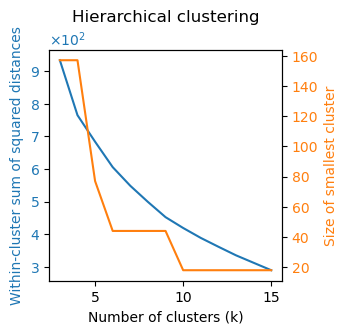

In [11]:
fig, ax1 = plt.subplots(figsize=(3,3))

color = 'tab:blue'
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Within-cluster sum of squared distances', color=color)
ax1.plot(cluschoice_results['k'], cluschoice_results['avg_within_cluster_sq_dist'], color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax1.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax1.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Size of smallest cluster', color=color)
ax2.plot(cluschoice_results['k'], cluschoice_results['smallest_cluster_size'], color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Hierarchical clustering')
plt.savefig(fig_dir+'interaction_cluster_decisionplot_2.pdf',bbox_inches='tight')
plt.show()

In [12]:
cluschoice_results
# k = 5

,k,avg_within_cluster_sq_dist,smallest_cluster_size
0,3,933.596237,157
1,4,765.021921,157
2,5,683.610296,77
3,6,605.640842,44
4,7,548.377848,44
5,8,498.957761,44
6,9,452.239394,44
7,10,419.010210,18
8,11,388.533490,18
9,12,361.477701,18


In [13]:
k=5
#model = KMeans(n_clusters=k,random_state=0)
model = AgglomerativeClustering(n_clusters=k)
labels = model.fit_predict(df_wide)

In [14]:
#make a gene-cluster map df
df_wide.columns.name = None
df_wide['cluster_label']=labels
gene_cluster_map=df_wide[['cluster_label']].copy() 
gene_cluster_map['gene']=gene_cluster_map.index.to_numpy() 
gene_cluster_map.reset_index(drop=True, inplace=True)

In [14]:
# write this out
df_wide.to_csv(outfile_path)

In [15]:
df_long = (
    df_wide
    .reset_index()  # move Gene_snp_pair from index to a column
    .melt(id_vars=['gsp', 'cluster_label'], 
          value_vars=['wk12', 'wk20', 'wk28', 'wk36'],
          var_name='timepoint', 
          value_name='scaled_beta_sum')
)
df_long

,gsp,cluster_label,timepoint,scaled_beta_sum
0,ENSG00000001631_rs9656003,1,wk12,-0.892438
1,ENSG00000002726_rs6464100,2,wk12,1.459925
2,ENSG00000002933_rs6464102,1,wk12,-0.899925
3,ENSG00000003137_rs62147573,4,wk12,0.405782
4,ENSG00000004866_rs66758829,1,wk12,-1.134581
...,...,...,...,...
4767,ENSG00000287497_rs201037,1,wk36,1.044121
4768,ENSG00000287569_rs2386804,0,wk36,0.908639
4769,ENSG00000287576_rs4874144,3,wk36,-0.401349
4770,ENSG00000287586_rs436132,1,wk36,1.416892


In [16]:
df_long['cluster_label'].value_counts()/4

cluster_label
1    450.0
3    309.0
0    200.0
2    157.0
4     77.0
Name: count, dtype: float64

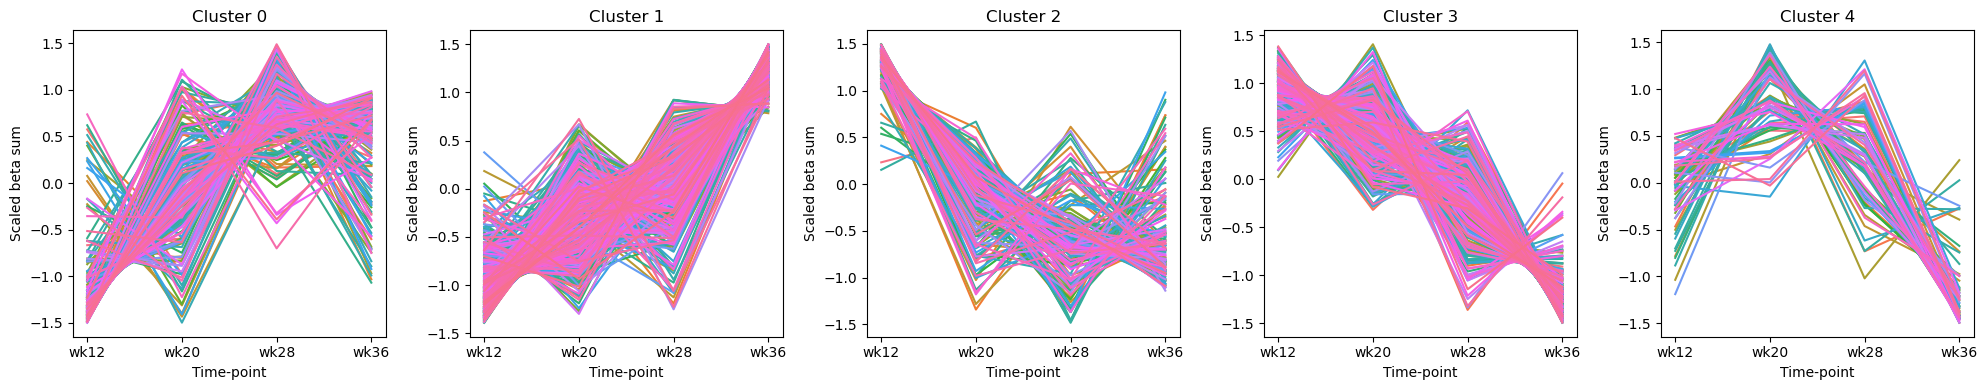

In [17]:
cols = 5
rows = math.ceil(k / cols)

timepoints = sorted(df_long['timepoint'].unique())

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4)) #, sharex=True, sharey=True
axes = axes.flatten()

for clus in range(k):
    ax = axes[clus]
    plotvars_subset=df_long[df_long['cluster_label']==clus]
    sb.lineplot(data=plotvars_subset, x='timepoint', y='scaled_beta_sum', hue='gsp',legend=False,ax=ax)

    ax.set_xlabel('Time-point')
    ax.set_ylabel('Scaled beta sum')
    ax.set_title('Cluster '+str(clus))
    ax.set_xticks(timepoints)

for j in range(clus + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(fig_dir+'int_5clusters_v3.pdf',bbox_inches='tight')
plt.show()